# Final Project Analysis

## Part A

This section addresses the following questions:

1. Do incidence rates for the selected major diseases change over time from 2001 to 2019?
2. Are time trends similar across diseases, or do some diseases change faster than others?
3. After controlling for county and disease, is there still an overall time trend in disease burden?
4. Does adding sex improve the county-year regression model?

In [1]:
# load packages and helper functions
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)

def standardize(x):
    x = np.asarray(x)
    return (x - np.mean(x)) / np.std(x, ddof=1)

def decision(pvalue, alpha=0.05):
    if pvalue < alpha:
        return f"reject H0 (p={pvalue:.4g})"
    return f"fail to reject H0 (p={pvalue:.4g})"

Load and Prepare the Data

identified from main.ipynb
- remove the disease category `Other`
- recompute `Rate` from `Cases` and `Population` for consistency
- remove `County == "California"` because that row is a statewide aggregate rather than a county
- remove `Sex == "Total"` because the regression analysis uses sex as an explicit predictor

In [3]:
# load the dataset and keep county-level male/female rows
diseases = pd.read_csv("diseases.csv")
diseases = diseases[diseases["Disease"] != "Other"].copy()

diseases["Cases"] = pd.to_numeric(diseases["Cases"], errors="coerce")
diseases["Population"] = pd.to_numeric(diseases["Population"], errors="coerce")
diseases["Rate"] = diseases["Cases"] / diseases["Population"] * 100000

analysis_df = diseases[
    (diseases["County"] != "California") &
    (diseases["Sex"].isin(["Female", "Male"]))
].copy()

analysis_df["Year_c"] = analysis_df["Year"] - analysis_df["Year"].min()

print("analysis shape:", analysis_df.shape)
print("year range:", analysis_df["Year"].min(), "to", analysis_df["Year"].max())
print("number of counties:", analysis_df["County"].nunique())
print("number of diseases:", analysis_df["Disease"].nunique())
print("sex values:", analysis_df["Sex"].unique())

analysis shape: (107764, 10)
year range: 2001 to 2019
number of counties: 58
number of diseases: 53
sex values: ['Female' 'Male']



- focus on the top 3 diseases by total number of cases in the filtered county-level data.
- these diseases carry the most burden in the dataset
- they have enough data across counties and years to support regression
- they reduce noise from very rare diseases with many zero-count observations

In [4]:
# choose the top 3 diseases by total cases and drop suppressed rows
top3 = (
    analysis_df.groupby("Disease")["Cases"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

focus_diseases = top3.index.tolist()
focus_df = analysis_df[analysis_df["Disease"].isin(focus_diseases)].copy()
focus_df = focus_df.dropna(subset=["Cases", "Population", "Rate"]).copy()

print("Selected diseases:")
print(top3)
print()
print("Focused dataset shape after dropping suppressed rows:", focus_df.shape)
print(focus_df.groupby("Disease").size())

Selected diseases:
Disease
Campylobacteriosis    126532.0
Salmonellosis          89578.0
Coccidioidomycosis     73174.0
Name: Cases, dtype: float64

Focused dataset shape after dropping suppressed rows: (5166, 10)
Disease
Campylobacteriosis    1618
Coccidioidomycosis    1914
Salmonellosis         1634
dtype: int64


In [5]:
# summarize the final regression sample

focus_summary = focus_df.groupby("Disease").agg(
    total_cases=("Cases", "sum"),
    mean_rate=("Rate", "mean"),
    median_rate=("Rate", "median"),
    max_rate=("Rate", "max")
).sort_values("total_cases", ascending=False)

focus_summary

,total_cases,mean_rate,median_rate,max_rate
Disease,,,,
Campylobacteriosis,126532.0,18.690036,18.225048,80.152358
Salmonellosis,89578.0,10.971525,11.748384,48.543689
Coccidioidomycosis,73174.0,11.411781,0.842517,405.723191


Visualize Average Trends Over Time

1. look at average county-level incidence rates by year for the selected diseases

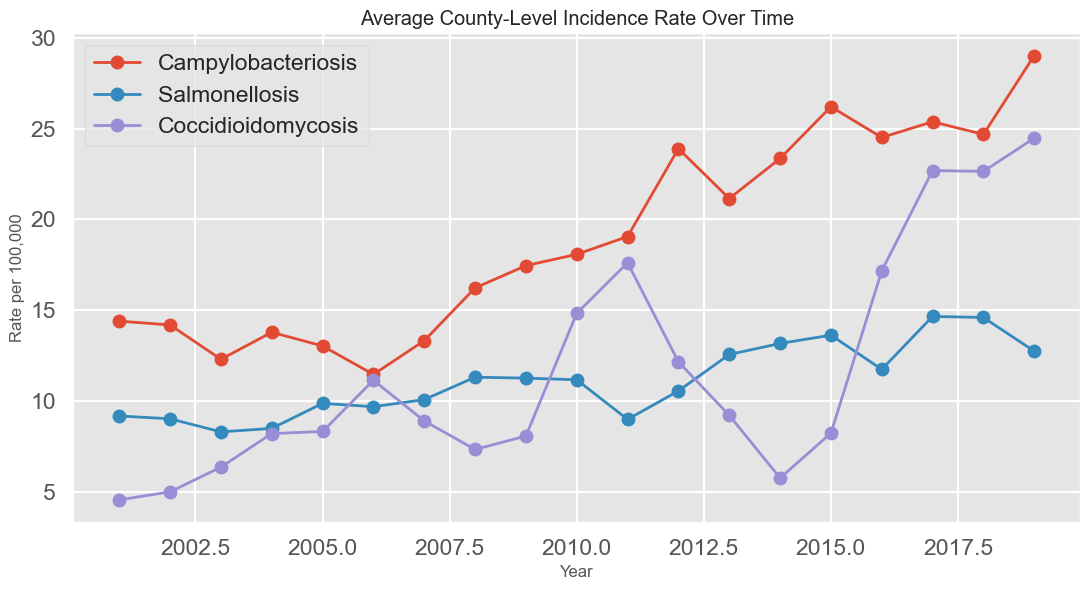

In [35]:
# calculate average yearly rates for each selected disease
yearly_disease = (
    focus_df.groupby(["Year", "Disease"], as_index=False)["Rate"]
    .mean()
)

plt.figure(figsize=(11, 6))
for disease in focus_diseases:
    sub = yearly_disease[yearly_disease["Disease"] == disease]
    plt.plot(sub["Year"], sub["Rate"], marker="o", linewidth=2, label=disease)
plt.title("Average County-Level Incidence Rate Over Time")
plt.ylabel("Rate per 100,000")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


$
\text{Rate} = \beta_0 + \beta_1 \cdot \text{Year}
$

In [36]:
# fit a simple year vs rate regression for each disease
simple_results = []

for disease in focus_diseases:
    sub = yearly_disease[yearly_disease["Disease"] == disease].copy()
    model = smf.ols("Rate ~ Year", data=sub).fit()
    simple_results.append({
        "Disease": disease,
        "Slope_per_year": model.params["Year"],
        "pvalue": model.pvalues["Year"],
        "R_squared": model.rsquared
    })

simple_results = pd.DataFrame(simple_results).sort_values("Slope_per_year", ascending=False)
simple_results

,Disease,Slope_per_year,pvalue,R_squared
0,Campylobacteriosis,0.922630,5.249407e-09,0.871929
2,Coccidioidomycosis,0.854594,1.630886e-04,0.576525
1,Salmonellosis,0.311030,1.373772e-06,0.755274


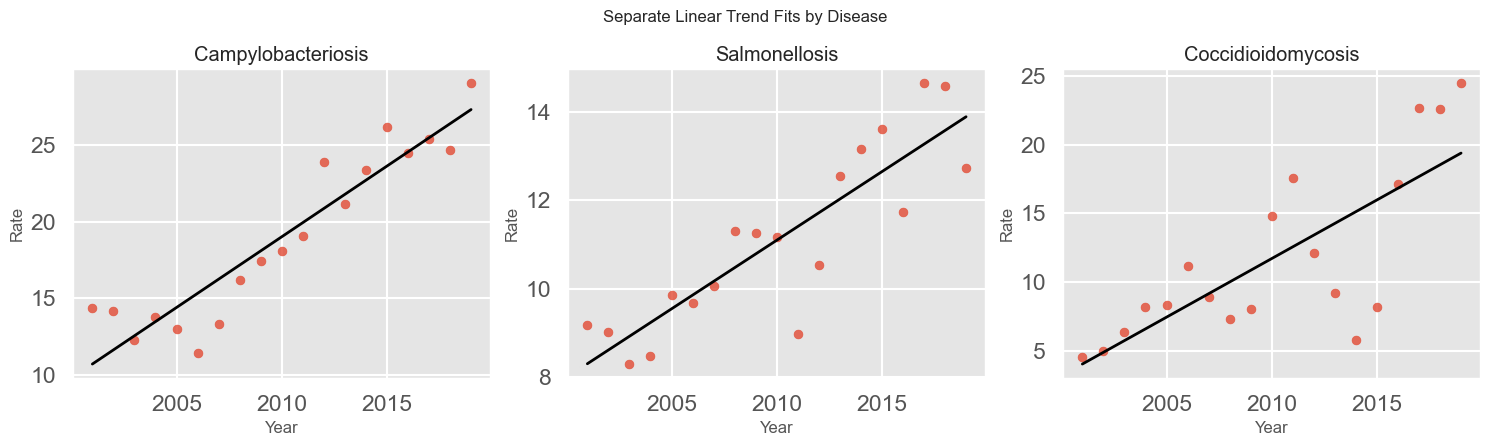

In [37]:
# plot the simple trend lines for each disease
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax, disease in zip(axes, focus_diseases):
    sub = yearly_disease[yearly_disease["Disease"] == disease].copy()
    model = smf.ols("Rate ~ Year", data=sub).fit()
    ax.scatter(sub["Year"], sub["Rate"], s=40, alpha=0.8)
    ax.plot(sub["Year"], model.fittedvalues, color="black", linewidth=2)
    ax.set_title(disease)
    ax.set_xlabel("Year")
    ax.set_ylabel("Rate")

fig.suptitle("Separate Linear Trend Fits by Disease")
plt.tight_layout()
plt.show()

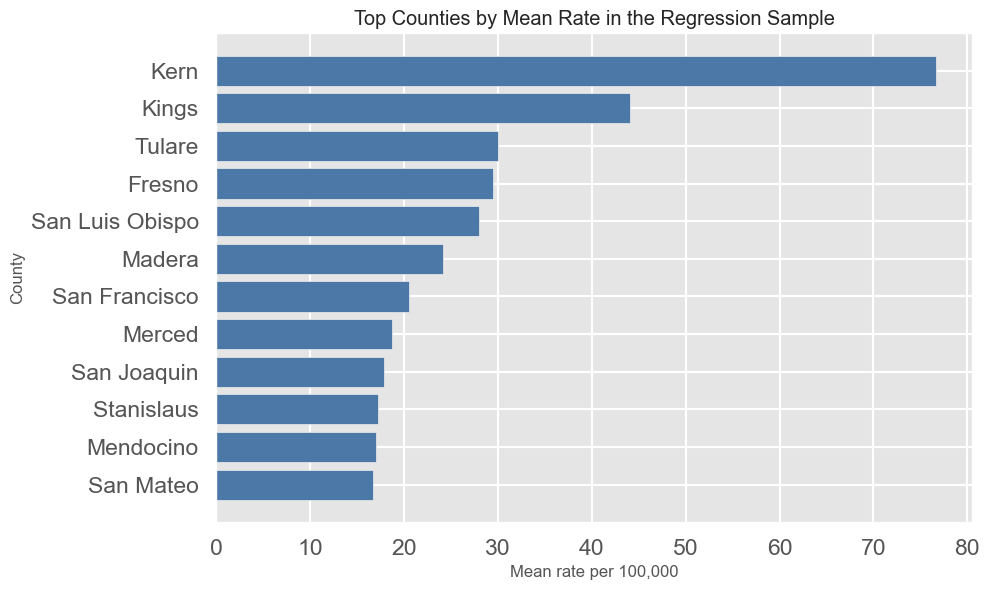

County
Kern               76.666874
Kings              44.117427
Tulare             30.025068
Fresno             29.486039
San Luis Obispo    28.030811
Madera             24.178377
San Francisco      20.561356
Merced             18.749785
San Joaquin        17.880392
Stanislaus         17.199413
Mendocino          16.996039
San Mateo          16.709038
Name: Rate, dtype: float64

In [38]:
# show which counties have the highest average rates in this sample
top_counties = (
    focus_df.groupby("County")["Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 6))
plt.barh(top_counties.index, top_counties.values, color="#4C78A8")
plt.gca().invert_yaxis()
plt.title("Top Counties by Mean Rate in the Regression Sample")
plt.xlabel("Mean rate per 100,000")
plt.ylabel("County")
plt.tight_layout()
plt.show()

top_counties

County-Year Regression Model

$
\text{Rate}_{i} = \beta_0 + \beta_1 \cdot \text{Year}_i + \alpha_{d(i)} + \gamma_{c(i)} + \varepsilon_i
$

- `Year_c` is the centered year variable
- `C(Disease)` controls for differences in baseline rates across diseases
- `C(County)` controls for persistent county-level differences

In [39]:
# fit the main county-year regression with disease and county controls
model_main = smf.ols("Rate ~ Year_c + C(Disease) + C(County)", data=focus_df).fit()

print(model_main.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     39.07
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        18:06:15   Log-Likelihood:                -22915.
No. Observations:                5166   AIC:                         4.595e+04
Df Residuals:                    5105   BIC:                         4.635e+04
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

Do Trends Differ by Disease?


$
\text{Rate}_{i} = \beta_0 + \beta_1 \cdot \text{Year}_i + \alpha_{d(i)} + \gamma_{c(i)} + \delta_{d(i)} \cdot \text{Year}_i + \varepsilon_i
$

In [40]:
# test whether time trends differ across diseases with an interaction model
model_interaction = smf.ols("Rate ~ Year_c * C(Disease) + C(County)", data=focus_df).fit()
interaction_compare = sm.stats.anova_lm(model_main, model_interaction)

print(model_interaction.summary().tables[1])
print()
interaction_compare

                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  11.9231      2.127      5.606      0.000       7.753      16.093
C(Disease)[T.Coccidioidomycosis]           -5.9489      1.323     -4.498      0.000      -8.542      -3.356
C(Disease)[T.Salmonellosis]                -2.4175      1.341     -1.803      0.071      -5.046       0.211
C(County)[T.Alpine]                       -14.1227      2.715     -5.202      0.000     -19.445      -8.800
C(County)[T.Amador]                       -11.2829      5.206     -2.167      0.030     -21.489      -1.077
C(County)[T.Butte]                         -0.4247      2.715     -0.156      0.876      -5.747       4.898
C(County)[T.Calaveras]                    -10.5130      4.993     -2.106      0.035     -20.301      -0.726
C(County)[T.Colusa]         

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,5105.0,2.155714e+06,0.0,NaN,NaN,NaN
1,5103.0,2.143893e+06,2.0,11821.52791,14.069093,8.065936e-07


Add Sex as an Additional Predictor

$
\text{Rate}_{i} = \beta_0 + \beta_1 \cdot \text{Year}_i + \alpha_{d(i)} + \gamma_{c(i)} + \eta_{s(i)} + \varepsilon_i
$

In [41]:
# add sex to see if it improves the model after controlling for time county and disease
model_sex = smf.ols("Rate ~ Year_c + C(Disease) + C(County) + C(Sex)", data=focus_df).fit()
sex_compare = sm.stats.anova_lm(model_main, model_sex)

print(model_sex.summary().tables[1])
print()
sex_compare

                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           11.6583      2.037      5.723      0.000       7.664      15.652
C(Disease)[T.Coccidioidomycosis]    -5.6044      0.706     -7.938      0.000      -6.989      -4.220
C(Disease)[T.Salmonellosis]         -7.4015      0.720    -10.274      0.000      -8.814      -5.989
C(County)[T.Alpine]                -14.1227      2.713     -5.206      0.000     -19.440      -8.805
C(County)[T.Amador]                -11.1279      5.202     -2.139      0.032     -21.325      -0.931
C(County)[T.Butte]                  -0.4247      2.713     -0.157      0.876      -5.742       4.893
C(County)[T.Calaveras]             -11.0995      4.984     -2.227      0.026     -20.871      -1.328
C(County)[T.Colusa]                -11.9624      4.211     -2.841      0.005     -20.217   

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,5105.0,2.155714e+06,0.0,NaN,NaN,NaN
1,5104.0,2.140658e+06,1.0,15056.334693,35.899021,2.220567e-09



combine both into one larger model that includes:

- county controls
- disease controls
- a sex effect
- disease-specific time slopes through `Year_c * C(Disease)`

In [42]:
# fit the fullest model with disease-specific trends and sex
model_full = smf.ols("Rate ~ Year_c * C(Disease) + C(County) + C(Sex)", data=focus_df).fit()
full_compare = sm.stats.anova_lm(model_sex, model_full)

print(model_full.summary())
print()
full_compare

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     38.68
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        18:06:15   Log-Likelihood:                -22883.
No. Observations:                5166   AIC:                         4.589e+04
Df Residuals:                    5102   BIC:                         4.631e+04
Df Model:                          63                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,5104.0,2.140658e+06,0.0,NaN,NaN,NaN
1,5102.0,2.128837e+06,2.0,11821.52791,14.165821,7.326234e-07


Model Comparison Summary

In [43]:
# compare the models using r-squared and aic
comparison = pd.DataFrame({
    "Model": [
        "Main: Year + Disease + County",
        "Interaction: Year * Disease + County",
        "Add Sex: Year + Disease + County + Sex",
        "Full: Year * Disease + County + Sex"
    ],
    "R_squared": [
        model_main.rsquared,
        model_interaction.rsquared,
        model_sex.rsquared,
        model_full.rsquared
    ],
    "Adj_R_squared": [
        model_main.rsquared_adj,
        model_interaction.rsquared_adj,
        model_sex.rsquared_adj,
        model_full.rsquared_adj
    ],
    "AIC": [
        model_main.aic,
        model_interaction.aic,
        model_sex.aic,
        model_full.aic
    ]
})

comparison

,Model,R_squared,Adj_R_squared,AIC
0,Main: Year + Disease + County,0.314668,0.306613,45952.974174
1,Interaction: Year * Disease + County,0.318426,0.310145,45928.566851
2,Add Sex: Year + Disease + County + Sex,0.319455,0.311321,45918.766260
3,Full: Year * Disease + County + Sex,0.323213,0.314856,45894.158581


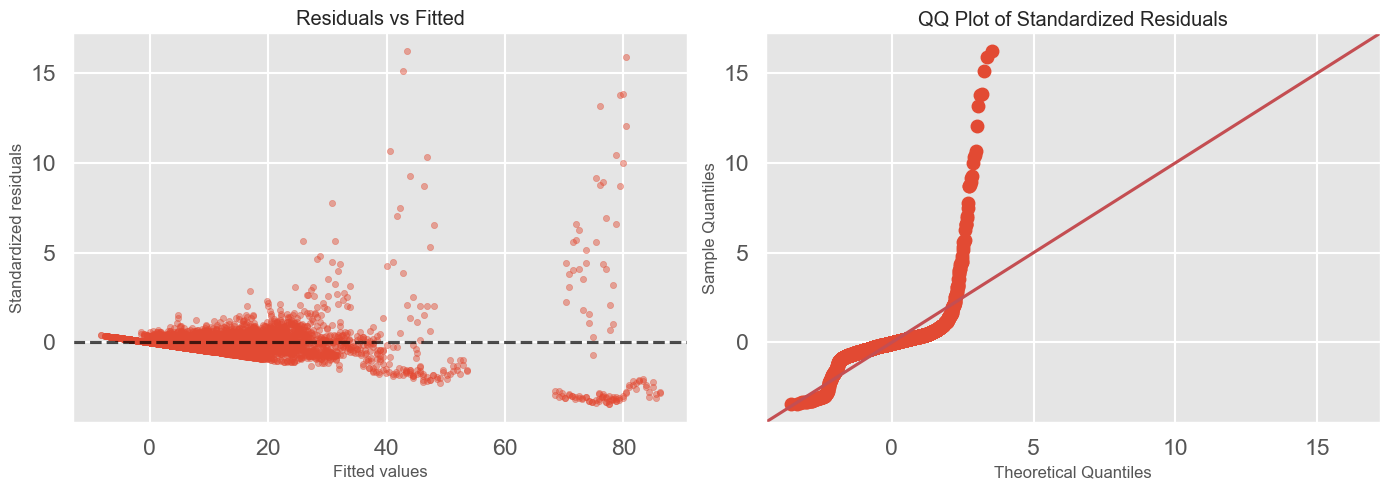

Shapiro-Wilk statistic: 0.4136
reject H0 (p=2.844e-37)


In [44]:
# check residual plots and a normality test for the main model
residuals = model_main.resid
fitted = model_main.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(fitted, standardize(residuals), s=20, alpha=0.45)
axes[0].axhline(0, color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Standardized residuals")

sm.qqplot(standardize(residuals), stats.norm, line="45", ax=axes[1])
axes[1].set_title("QQ Plot of Standardized Residuals")

plt.tight_layout()
plt.show()

resid_sample = pd.Series(standardize(residuals)).sample(min(len(residuals), 500), random_state=42)
shapiro_stat, shapiro_pvalue = stats.shapiro(resid_sample)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(decision(shapiro_pvalue))

In [45]:
# collect the main numbers that can go into the report
report_numbers = {
    "Main model year coefficient": model_main.params["Year_c"],
    "Main model year p-value": model_main.pvalues["Year_c"],
    "Interaction model comparison p-value": interaction_compare.loc[1, "Pr(>F)"],
    "Sex model comparison p-value": sex_compare.loc[1, "Pr(>F)"],
    "Full model comparison p-value": full_compare.loc[1, "Pr(>F)"],
    "Main model R-squared": model_main.rsquared,
    "Full model R-squared": model_full.rsquared
}

pd.Series(report_numbers)

Main model year coefficient             5.658310e-01
Main model year p-value                 1.905733e-26
Interaction model comparison p-value    8.065936e-07
Sex model comparison p-value            2.220567e-09
Full model comparison p-value           7.326234e-07
Main model R-squared                    3.146680e-01
Full model R-squared                    3.232128e-01
dtype: float64

## Part B

This section will address: 

- Do infectious disease incidence rates differ across California counties? Which countie experience the highest disease burden? 
- Do infectious disease incidence rates differ significantly between males and females?
- Is disease occurence associated with sex?
- Do the formal statistical tests support the patterns observed during the EDA? 

#### County Differences

> Do disease rate differ across California counties?

Define $$H_0: \text{The distribution of disease rates is the same across all counties.}$$ 
$$H_A: \text{At least one county has a different distribution of disease rates.}$$

In [7]:
#Apply Kruskal-Walli Test here as the nonparametric alternative to ANOVA
from scipy.stats import kruskal

county_df = diseases[diseases["Sex"] != "Total"].copy()
groups = [grp["Rate"].dropna()for _, grp in county_df.groupby("County")]
kw_stat, kw_p = kruskal(*groups)

print("H statistic:", kw_stat)
print("p-value:", kw_p)

H statistic: 19220.249598157192
p-value: 0.0


The Kruskal-Wallis test was applied to determine whether disease rates differed across California counties. Since the p-value is less than 0.001 and $H=19220$, the test revealed a statistically significant difference in disease rate among counties. 

This result is consistnt with the EDA. Recall the visulizations earlier, variation is shown in average disease rate across counties, with counties such as Ker, Kingd, and San Francisco having higher rates than most of the counties. And the Kruskal-Wallis test here confimed that the observed county-level differences are statistically significant and unlikely to be due to the random variation. 

In [28]:
county_rank = (
    county_df.groupby("County")["Rate"]
    .mean()
    .sort_values(ascending=False)
)

county_rank.head(10)

County
Kern               4.928389
Kings              2.875193
San Francisco      2.545568
Fresno             2.133024
San Luis Obispo    2.122702
Tulare             2.117086
Madera             1.769072
Marin              1.612659
San Mateo          1.596940
San Joaquin        1.536363
Name: Rate, dtype: float64

Hence, Kern has the highest disease burden. 

#### Sex Differences

> Do disease rates differ between males and females? 

Define $$H_0: \text{The distribution of disease rates is the same for males and females.}$$
$$H_A: \text{The distribution of disease rates differs between males and females.}$$

Recalled the bocplot in EDA, the diseases rates for both males and females are highly right-skewed with extreme outliers, so a nonparametrix Mann-Whitney U test is appropricate at here. Then, we will aply the Mann-Whitney U test to determine if there is a statistically significant difference between tw independent groups for ordinal dependent variable. 

In [16]:
from scipy.stats import mannwhitneyu

male_rate = sex_df.loc[sex_df["Sex"] == "Male", "Rate"].dropna()
female_rate = sex_df.loc[sex_df["Sex"] == "Female", "Rate"].dropna()

u_stat, p_val = mannwhitneyu(
    male_rate,
    female_rate,
    alternative="two-sided"
)

print("U statistic =", u_stat)
print("p-value =", p_val)

U statistic = 1408981229.5
p-value = 1.62197450738929e-07


Since the p-value is less than 0.001, the null hypothesis got rejected. Hence, the Mann-Whiteney U test revealed a statistically significant difference in disease rates between the male and the female. 

In [18]:
sex_df.groupby("Sex")["Rate"].describe()

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
Female,52751.0,0.820588,5.061768,0.0,0.0,0.0,0.0,327.020303
Male,52751.0,1.049384,7.413147,0.0,0.0,0.0,0.0,405.723191


The boxplot suggests that males tend to have more extreme disease rates than females. And the average disease rate was higher among males (mean=1.05) than females(mean=0.82). The Mann-Whiteney U test confirmed that the overall distributions differed between males and females. However, is the diseases occurence associated with sex? 

#### Disease Occurence by Sex

> Are males and females tend to equally likely to have a positive diseae rate?

Define $$H_0:\text{ The proportion of positive disease rates is the same for males and females.}$$
$$H_A:\text{ Disease occurrence is associated with sex.}$$

In [21]:
diseases.columns

Index(['Disease', 'County', 'Year', 'Sex', 'Cases', 'Population', 'Rate',
       'Lower_95__CI', 'Upper_95__CI'],
      dtype='object')

In [25]:
sex_df = diseases[diseases["Sex"].isin(["Male","Female"])].copy()

sex_df["Rate_Group"] = np.where(
    sex_df["Rate"] > 0,
    "Positive",
    "Zero"
)

sex_df.head()

,Disease,County,Year,Sex,Cases,Population,Rate,Lower_95__CI,Upper_95__CI,Rate_Group
0,Amebiasis,Alameda,2001,Female,7.0,746596,0.937589,0.377,1.932,Positive
1,Amebiasis,Alameda,2001,Male,9.0,718968,1.251794,0.572,2.376,Positive
3,Amebiasis,Alameda,2002,Female,4.0,747987,0.534769,0.146,1.369,Positive
4,Amebiasis,Alameda,2002,Male,5.0,720481,0.693981,0.225,1.620,Positive
6,Amebiasis,Alameda,2003,Female,1.0,747441,0.133790,0.003,0.745,Positive


In [26]:
table = pd.crosstab(
    sex_df["Sex"],
    sex_df["Rate_Group"]
)

table

Rate_Group,Positive,Zero
Sex,,
Female,9581,45230
Male,10217,44594


In [27]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square =", chi2)
print("Degrees of freedom =", dof)
print("p-value =", p)

Chi-square = 24.856012635122756
Degrees of freedom = 1
p-value = 6.177606037654234e-07


A chi-square test of independence was conducted to examine the relatinship between sec and disease occurence. The test here is statistically significant ($p$<0.001), which makes $H_0$ get rejected and indicates that disease occurence is associated with sex. 